In [1]:
from torch import nn
import torch
from torch.nn import functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential( #Esegue in sequenza le operazioni definite al suo interno
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding='same'),
        )

    def forward(self, x):
        return self.double_conv(x)

In [2]:
class downsample(nn.Module):
    """ In questo scenario, prima eseguiamo il downsampling, quindi applichiamo la riduzione della 
    dimensione spaziale dell'immagine utilizzando un'operazione di pooling (in questo caso, MaxPool2d)
    e successivamente applichiamo il DoubleConv per estrarre le caratteristiche dall'immagine ridotta. """
    def __init__(self, in_channels, out_channels):
        super(downsample, self).__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(kernel_size=2), #Riduce la dimensione spaziale dell'immagine di 2. Il kernel di pooling di dimensione 2x2 viene applicato all'immagine, e il valore massimo all'interno di ogni finestra di pooling viene selezionato per creare l'immagine ridotta.
            DoubleConv(in_channels, out_channels) #Applica il DoubleConv definito in precedenza. 
        )

    def forward(self, x):
        return self.down(x)

In [3]:
class upsample(nn.Module):
    def __init__(self, in_channels, out_channels, skip_channels):
        super(upsample, self).__init__()
        self.up = nn.Upsample(scale_factor=2) #Aumenta la dimensione spaziale dell'immagine di 2. Utilizza l'interpolazione lineare per ingrandire l'immagine, raddoppiando le sue dimensioni spaziali.
        self.conv = DoubleConv(in_channels + skip_channels, out_channels) #Applica il DoubleConv definito in precedenza.
        #Il numero di canali in ingresso per il DoubleConv è la somma dei canali dell'immagine upsampled (in_channels) e dei canali dell'immagine skip (skip_channels), poiché queste due immagini vengono concatenate lungo la dimensione dei canali prima di essere passate al DoubleConv.

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False) #Se le dimensioni spaziali dell'immagine upsampled (x) non corrispondono a quelle dell'immagine skip, viene utilizzata la funzione F.interpolate per ridimensionare l'immagine upsampled alle dimensioni dell'immagine skip. L'interpolazione bilineare viene utilizzata per mantenere la qualità dell'immagine durante il ridimensionamento.
            #Anche scalando l'immagine con un fattore di 2, le dimensioni potrebbero non coincidere nel caso di input con dimensioni dispari, quindi è necessario eseguire un ulteriore ridimensionamento per garantire che le dimensioni siano compatibili per la concatenazione.
        x = torch.cat([x, skip], dim=1) #Concatena l'immagine upsampled con l'immagine skip (che proviene dalla fase di downsampling) lungo la dimensione dei canali (dim=1).
        """
        [batch, canali, altezza, larghezza]
            0       1       2        3
        """
        return self.conv(x)

In [4]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256]):
        super(UNet, self).__init__()
        self.input = DoubleConv(in_channels, features[0])
        self.down = downsample(features[0], features[1])
        self.bottleneck = downsample(features[1], features[2])
        self.up1 = upsample(features[2], features[1], features[1]) 
        self.up2 = upsample(features[1], features[0], features[0])
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1) #Processa ogni pixcel isolatamente, serve per combinare le informazioni provenineti dai diversi channel.

    def forward(self, x):
        
        # Encoder
        ConvolutionedInput = self.input(x) 
        douwn = self.down(ConvolutionedInput)
        bottleneck = self.bottleneck(douwn)
        
        # Decoder
        up1 = self.up1(bottleneck, douwn) #Passa il bottleneck e la connessione skip (douwn) alla prima fase di upsampling.        
        up2 = self.up2(up1, ConvolutionedInput) #Passa l'output della prima fase di upsampling (up1) e la connessione skip (input) alla seconda fase di upsampling.

        return self.final_conv(up2) 

⚠️: Batch 103/104
👉 Epoch 0, Loss: 0.0012764123966917396, LR: [0.0006545084971874861]
⚠️: Batch 103/104
👉 Epoch 1, Loss: 0.0005771780852228403, LR: [9.549150281252963e-05]
⚠️: Batch 103/104
👉 Epoch 2, Loss: 0.000513765960931778, LR: [9.549150281252863e-05]


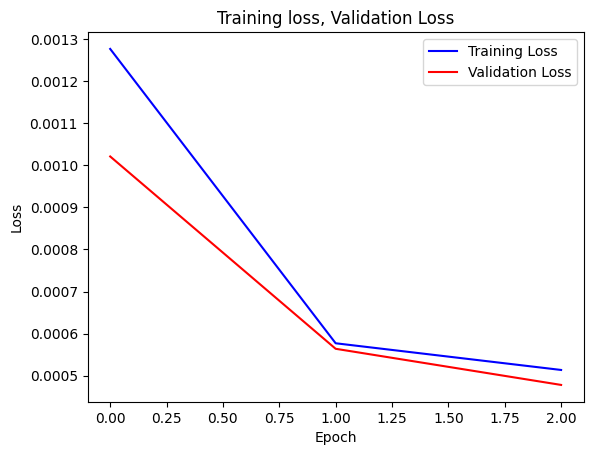

UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

In [ ]:
from MyUtilities import MayoDataset
from MyUtilities import MyTrainer
from torch.utils.data import DataLoader

testDataset = MayoDataset(data_path='./Mayo/train', data_shape_HR=(256, 256), data_shape_LR=(128, 128), noise_level=0.005, saveModel=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

modelUNetAttention = UNet(in_channels=1, out_channels=1)

optimizerUNet = torch.optim.Adam(modelUNetAttention.parameters(), lr=1e-3)

trainerUNet = MyTrainer(
    model=modelUNetAttention, 
    train_loader=testLoader, 
    optimizer=optimizerUNet,
    loss_fn=torch.nn.MSELoss(),
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizerUNet, T_max=10), 
    num_epochs=3,
    validation_set=next(iter(testLoader))
    )

trainerUNet.train()
trainerUNet.test()

